# Session 3 — Sentence-Level Analysis
## Measure 3: Sentence Embeddings (LLMs as Semantic Encoders)

### What are Sentence Embeddings?
Sentence embeddings are **dense vector representations** of sentences that capture their semantic meaning in a high-dimensional space. Unlike traditional word-based approaches, sentence embeddings encode the entire meaning of a sentence into a single fixed-length vector (typically 384-768 dimensions).

### How They Work
Modern sentence embedding models (like SBERT - Sentence-BERT) use **transformer architectures** pre-trained on massive text corpora. These models:
- Convert sentences into numerical vectors where semantically similar sentences are close together in vector space
- Capture context, syntax, and semantic relationships
- Enable comparison of sentences based on meaning rather than just word overlap

### Key Applications in NLP
1. **Semantic Similarity**: Measure how similar two sentences are in meaning
2. **Information Retrieval**: Find relevant documents or passages based on semantic search
3. **Text Clustering**: Group similar sentences or documents together
4. **Duplicate Detection**: Identify paraphrases or semantically identical content
5. **Question Answering**: Match questions with relevant answers
6. **Content Recommendation**: Suggest similar content based on semantic understanding

### Why Use Sentence Embeddings?
- **Beyond Keywords**: Captures meaning even when different words are used
- **Efficient**: Pre-computed embeddings allow fast similarity comparisons
- **Robust**: Works across different phrasings and writing styles
- **Multilingual**: Many models support cross-lingual semantic search

### This Demonstration
We'll use the **all-MiniLM-L6-v2** model to:
- Encode example sentences into semantic vectors
- Visualize their relationships in 2D space using PCA
- Compute similarity scores between sentence pairs

In [15]:
# First, add the data loading functions from our previous notebook
import re
from collections import Counter
import matplotlib.pyplot as plt

def load_book(filepath):
    """Load and clean book text from Project Gutenberg"""
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()
    
    # Remove Project Gutenberg headers/footers
    if 'CHAPTER I' in text:
        start = text.find('CHAPTER I')
        text = text[start:]
    elif '*** START OF' in text:
        start = text.find('*** START OF')
        text = text[start + 100:]
    
    if '*** END OF' in text:
        end = text.find('*** END OF')
        text = text[:end]
    elif 'End of Project Gutenberg' in text:
        end = text.find('End of Project Gutenberg')
        text = text[:end]
    
    return text.strip()

def analyze_sentences(text, book_name):
    """Split text into sentences and return the sentence list"""
    sentences = re.split(r'[.!?]+\s+', text.strip())
    sentences = [s.strip() for s in sentences if s.strip() and len(s.split()) > 2]
    
    print(f"{book_name}: Loaded {len(sentences)} sentences.")
    return sentences

# Load the book texts (assuming they are in the ../data/ directory)
# NOTE: Update these file paths if they are in a different location
try:
    crime_text = load_book('../data/Crime-punishment.txt')
    brothers_text = load_book('../data/The-BrothersKaramazov.txt')
    
    # Get the sentence lists
    crime_sents = analyze_sentences(crime_text, "Crime and Punishment")
    brothers_sents = analyze_sentences(brothers_text, "The Brothers Karamazov")

except FileNotFoundError:
    print("Error: Book files not found. Please make sure the file paths are correct.")
    print("Using demo sentences instead.")
    crime_sents = [] # Set to empty

Crime and Punishment: Loaded 12802 sentences.
The Brothers Karamazov: Loaded 18790 sentences.


In [16]:
# --- Cell 2: Load Model and Sample Sentences (Modified) ---
from sentence_transformers import SentenceTransformer, util
from sklearn.decomposition import PCA
import numpy as np

# Load pre-trained sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Take a random sample of 20 sentences from the book
if crime_sents:
    sample_size = 20
    # Ensure we don't sample more sentences than we have
    if len(crime_sents) > sample_size:
        sentences = random.sample(crime_sents, sample_size)
    else:
        sentences = crime_sents
    
    print(f"--- Using {sample_size} random sentences from Crime and Punishment ---")

else:
    print("Book data not loaded. Using 8 demo sentences instead.")
    sentences = [
        "Alice looked at the cat.", 
        "The cat stared back at Alice.",
        "Bob opened the door.",
        "The door was opened by Bob.",
        "The weather is beautiful today.",
        "It's a sunny and pleasant day.",
        "Programming is challenging.",
        "The ocean is vast and deep."
    ]

# Generate embeddings
embeddings = model.encode(sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented as a {embeddings.shape[1]}-dimensional vector\n")

--- Using 20 random sentences from Crime and Punishment ---
Embedding shape: (20, 384)
Each sentence is represented as a 384-dimensional vector



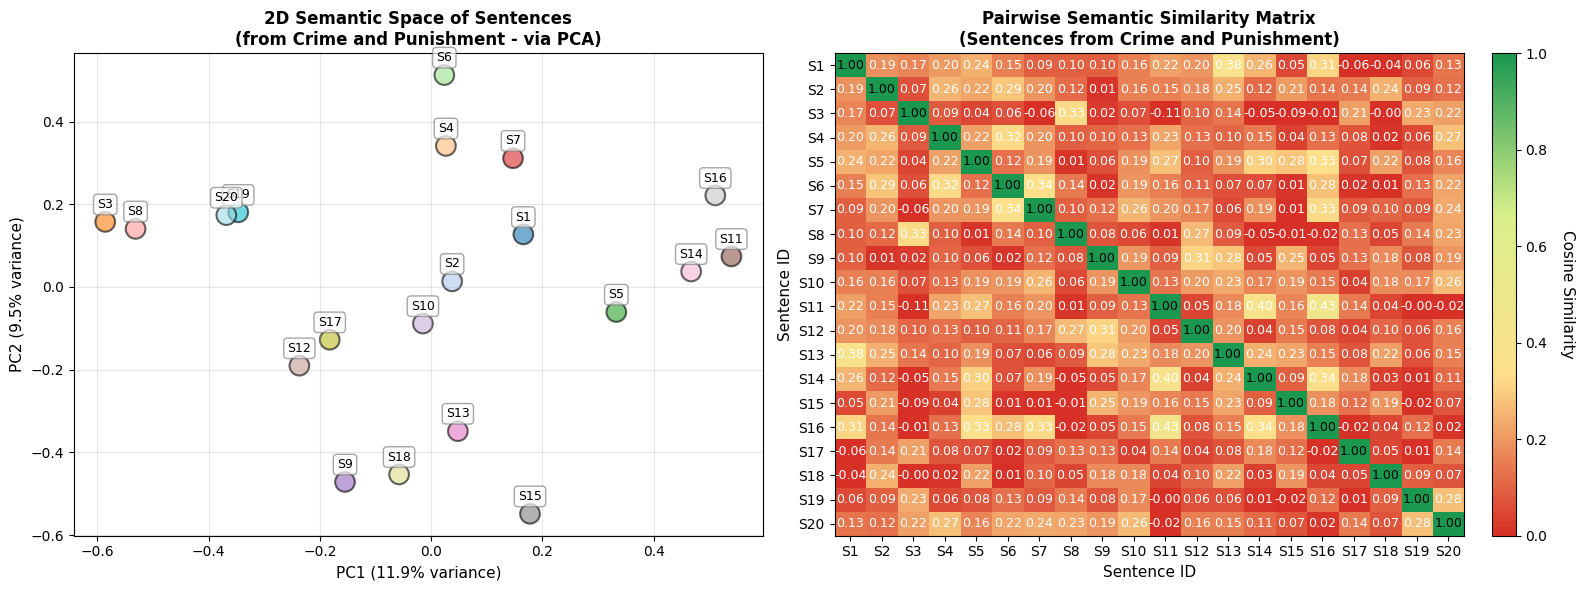


SENTENCE REFERENCE (Random Sample):
S1: This coincidence always seemed strange
to him
S2: “Have they caught the little girl and the
boy
S3: So it is and so it always will be
S4: Think of not telling us!”
    “How did you find out that the article was mine
S5: She could not have said, for instance, that she


                          635
                  fyodor dostoevsky

had foreseen something of the sort — and yet now, as
soon as he told her, she suddenly fancied that she had
really foreseen this very thing
S6: suggested!”
    “Brother, brother, what are you saying
S7: “Never mind,” he said, “I have come for this; I
have no lessons
S8: it’s better so
S9: At night I
had no light, I lay in the dark and I wouldn’t earn
money for candles
S10: Why, you
have shed blood!” cried Dounia in despair
S11: Nikodim Fomitch would have made some further
protest, but glancing at the head clerk who was look-
ing very hard at him, he did not speak
S12: haven’t I lived just now
S13: I saw
clear as d

In [17]:
# --- Cell 3: Visualization (Titles Modified) ---

# Create a more comprehensive visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: 2D PCA Visualization ---\n",
pca = PCA(n_components=2)
points = pca.fit_transform(embeddings)

ax1 = axes[0]
scatter = ax1.scatter(points[:, 0], points[:, 1], c=range(len(sentences)), 
                      cmap='tab20', s=200, alpha=0.6, edgecolors='black', linewidth=1.5)

# Add labels with better positioning
for i, (s, (x, y)) in enumerate(zip(sentences, points)):
    # Use numbered labels for the plot, we will print the reference below
    label = f"S{i+1}"
    ax1.annotate(label, (x, y), fontsize=9, ha='center', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'),
                xytext=(0, 10), textcoords='offset points')

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
# --- TITLE MODIFIED ---
ax1.set_title("2D Semantic Space of Sentences\n(from Crime and Punishment - via PCA)", 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# --- Plot 2: Similarity Heatmap ---\n",
from matplotlib.colors import LinearSegmentedColormap

# Compute cosine similarity matrix\n",
similarity_matrix = util.cos_sim(embeddings, embeddings).numpy()

ax2 = axes[1]
# Create custom colormap
colors = ['#d73027', '#fee08b', '#d9ef8b', '#1a9850']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('similarity', colors, N=n_bins)

im = ax2.imshow(similarity_matrix, cmap=cmap, aspect='auto', vmin=0, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Cosine Similarity', rotation=270, labelpad=20, fontsize=11)

# Set ticks and labels
ax2.set_xticks(range(len(sentences)))
ax2.set_yticks(range(len(sentences)))
short_labels = [f"S{i+1}" for i in range(len(sentences))]
ax2.set_xticklabels(short_labels, fontsize=10)
ax2.set_yticklabels(short_labels, fontsize=10)

# Add similarity scores as text
for i in range(len(sentences)):
    for j in range(len(sentences)):
        text_color = 'white' if similarity_matrix[i, j] < 0.5 else 'black'
        ax2.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                ha="center", va="center", color=text_color, fontsize=9)

# --- TITLE MODIFIED ---
ax2.set_title("Pairwise Semantic Similarity Matrix\n(Sentences from Crime and Punishment)", 
              fontsize=12, fontweight='bold')
ax2.set_xlabel("Sentence ID", fontsize=11)
ax2.set_ylabel("Sentence ID", fontsize=11)

plt.tight_layout()
plt.show()

# Print the sentences for reference
print("\n" + "="*80)
print("SENTENCE REFERENCE (Random Sample):")
print("="*80)
for i, sent in enumerate(sentences):
    print(f"S{i+1}: {sent}")
print("="*80)

### Interpreting the Results

**Left Plot - 2D Semantic Space:**
- Sentences with similar meanings cluster together in the vector space
- Distance between points indicates semantic dissimilarity
- PCA reduces the 384-dimensional embeddings to 2D for visualization
- Note: Some information is lost in dimension reduction (see variance percentages)

**Right Plot - Similarity Matrix:**
- Values range from 0 (completely dissimilar) to 1 (identical)
- Diagonal values are always 1.0 (sentence compared to itself)
- Higher values (green) indicate semantically similar sentences
- Lower values (red) indicate semantically different sentences

**Key Observations:**
- Paraphrases (e.g., "Alice looked at the cat" vs "The cat stared back at Alice") show high similarity
- Semantically related sentences cluster together in both visualizations
- Unrelated sentences have low similarity scores despite being grammatically correct

In [18]:
# Example: Finding most similar sentence pairs
print("\nTOP 5 MOST SIMILAR SENTENCE PAIRS:")
print("="*80)

# Get upper triangle indices (avoid duplicates and self-comparisons)
pairs = []
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        pairs.append((i, j, similarity_matrix[i, j]))

# Sort by similarity score
pairs.sort(key=lambda x: x[2], reverse=True)

# Display top 5
for rank, (i, j, score) in enumerate(pairs[:5], 1):
    print(f"{rank}. Similarity: {score:.4f}")
    print(f"   S{i+1}: {sentences[i]}")
    print(f"   S{j+1}: {sentences[j]}")
    print()


TOP 5 MOST SIMILAR SENTENCE PAIRS:
1. Similarity: 0.4331
   S11: Nikodim Fomitch would have made some further
protest, but glancing at the head clerk who was look-
ing very hard at him, he did not speak
   S16: He looked repeat-
edly at the clerk, partly no doubt because the latter
was staring persistently at him, obviously anxious to
enter into conversation

2. Similarity: 0.3990
   S11: Nikodim Fomitch would have made some further
protest, but glancing at the head clerk who was look-
ing very hard at him, he did not speak
   S14: There’s only one thing I can’t understand: what made
him risk such a contemptible action

3. Similarity: 0.3810
   S1: This coincidence always seemed strange
to him
   S13: I saw
clear as daylight how strange it is that not a single per-
son living in this mad world has had the daring to go
straight for it all and send it flying to the devil

4. Similarity: 0.3381
   S6: suggested!”
    “Brother, brother, what are you saying
   S7: “Never mind,” he said, “I

Crime and Punishment

In [19]:
import random

# Take a random sample of 20 sentences from the book
if crime_sents:
    sample_size = 20
    # Ensure we don't sample more sentences than we have
    if len(crime_sents) > sample_size:
        book_sample_sentences = random.sample(crime_sents, sample_size)
    else:
        book_sample_sentences = crime_sents
    
    print(f"--- Using {sample_size} random sentences from Crime and Punishment ---")
else:
    print("Book data not loaded, cannot create sample.")
    book_sample_sentences = [] # Set to empty

--- Using 20 random sentences from Crime and Punishment ---


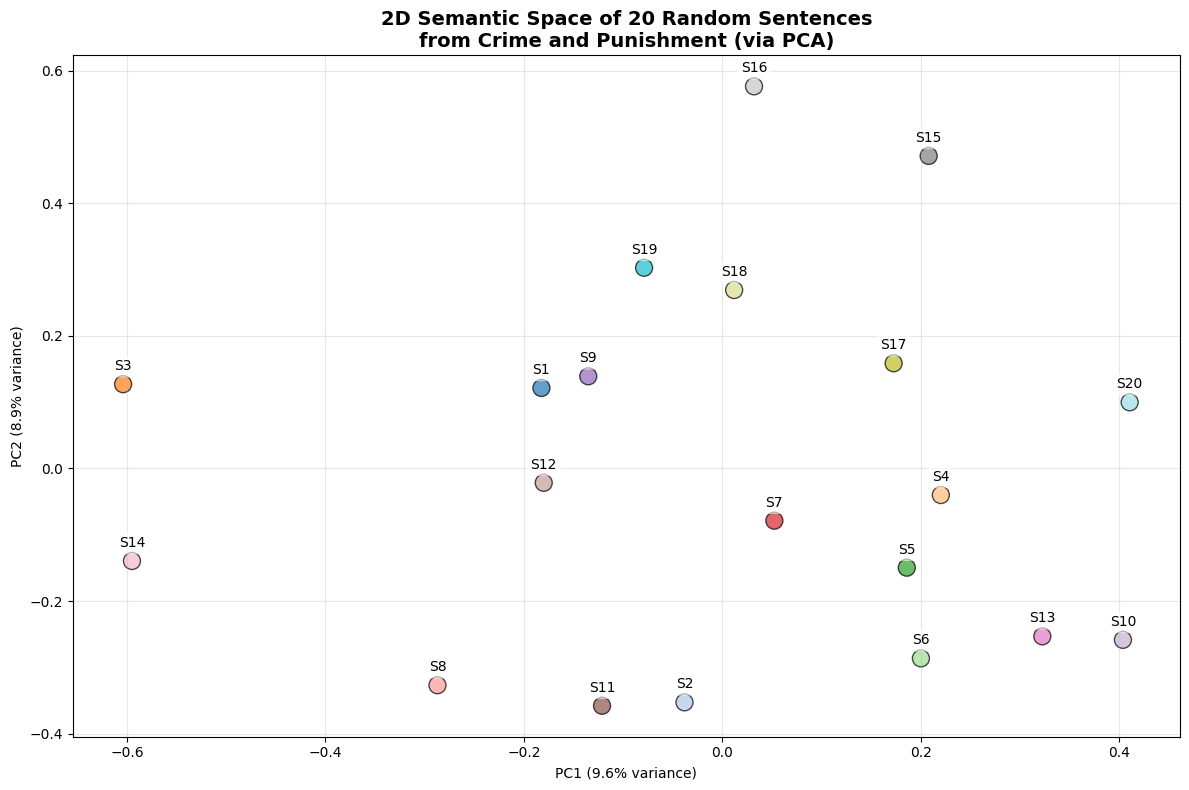

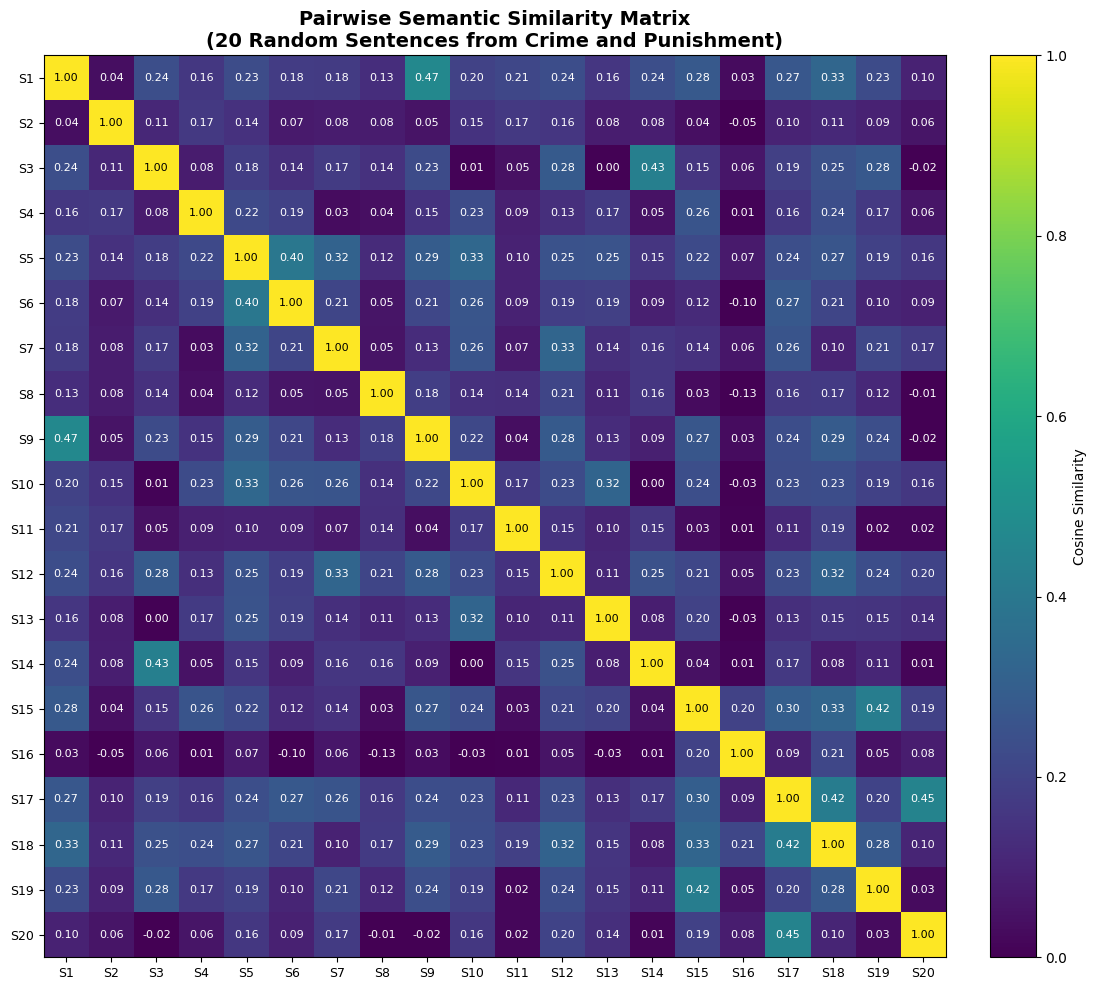


SENTENCE REFERENCE (Random Sample):
S1: But at last he lost all control and had the face to
make Dounia an open and shameful proposal, prom-
ising her all sorts of inducements and offering,
besides, to throw up everything and take her to
another estate of his, or even abroad
S2: I kept waiting on pur-
pose to understand it, for I must own even now it is
not quite logical
S3: “And mother never used
to say anything, but we knew that she liked it and
father knew it, too
S4: This noose, too,
he had designed a fortnight before
S5: At once he rushed to the light to examine the sock
and the rags
S6: He
tried to catch it, but the mouse ran to and fro in zig-
zags without leaving the bed, slipped between his fin-
gers, ran over his hand and suddenly darted under
the pillow
S7: The policeman, too,
stood in hesitation
S8: Good-bye, Sofya Semyonovna, my dear
S9: For a
minute he gazed at the delicate expressive face of his
betrothed, kissed the portrait and gave it to Dounia
S10: Dmitri didn’t
see

In [20]:
# Now, we re-run the logic from this notebook's Cell 2, 3, and 5
# but using our 'book_sample_sentences' variable

if book_sample_sentences:
    # 1. Generate embeddings for our sample
    book_embeddings = model.encode(book_sample_sentences)

    # 2. Create the 2D PCA Plot
    pca = PCA(n_components=2)
    book_points = pca.fit_transform(book_embeddings)

    fig, ax1 = plt.subplots(figsize=(12, 8))
    
    scatter = ax1.scatter(book_points[:, 0], book_points[:, 1], c=range(len(book_sample_sentences)), 
                          cmap='tab20', s=150, alpha=0.7, edgecolors='black')

    # Add labels
    for i, (s, (x, y)) in enumerate(zip(book_sample_sentences, book_points)):
        label = f"S{i+1}" # Just use numbers for the plot
        ax1.annotate(label, (x, y), fontsize=10, ha='center',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6, ec='none'),
                    xytext=(0, 10), textcoords='offset points')

    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax1.set_title("2D Semantic Space of 20 Random Sentences\nfrom Crime and Punishment (via PCA)", 
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3. Create the Similarity Matrix Plot
    fig, ax2 = plt.subplots(figsize=(12, 10))
    book_similarity_matrix = util.cos_sim(book_embeddings, book_embeddings).numpy()
    
    im = ax2.imshow(book_similarity_matrix, cmap='viridis', vmin=0, vmax=1)
    cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label('Cosine Similarity')

    ax2.set_xticks(range(len(book_sample_sentences)))
    ax2.set_yticks(range(len(book_sample_sentences)))
    short_labels = [f"S{i+1}" for i in range(len(book_sample_sentences))]
    ax2.set_xticklabels(short_labels, fontsize=9)
    ax2.set_yticklabels(short_labels, fontsize=9)
    ax2.set_title("Pairwise Semantic Similarity Matrix\n(20 Random Sentences from Crime and Punishment)", 
                  fontsize=14, fontweight='bold')
    
    # Add similarity scores as text
    for i in range(len(book_sample_sentences)):
        for j in range(len(book_sample_sentences)):
            text_color = 'white' if book_similarity_matrix[i, j] < 0.5 else 'black'
            ax2.text(j, i, f'{book_similarity_matrix[i, j]:.2f}',
                    ha="center", va="center", color=text_color, fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Print the sentence reference for our sample
    print("\n" + "="*80)
    print("SENTENCE REFERENCE (Random Sample):")
    print("="*80)
    for i, sent in enumerate(book_sample_sentences):
        print(f"S{i+1}: {sent}")
    print("="*80)

--- Using 20 random sentences from The Brothers Karamazov ---


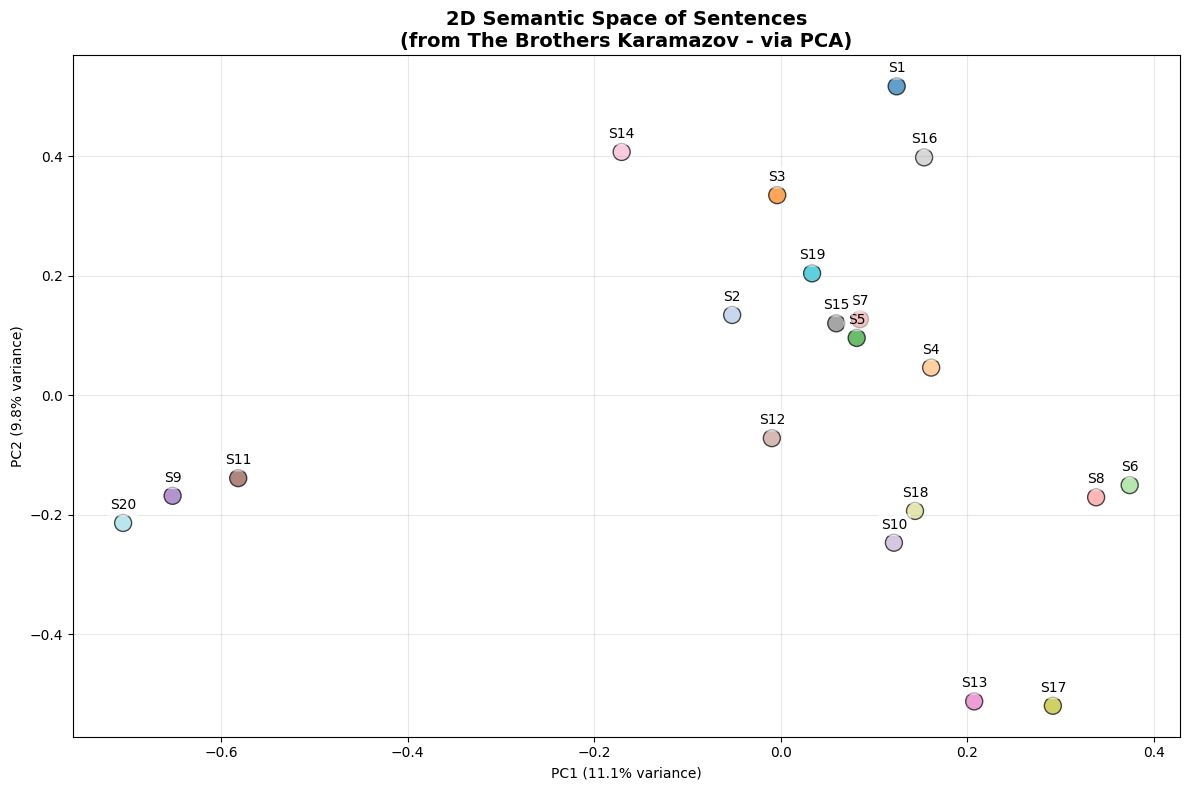

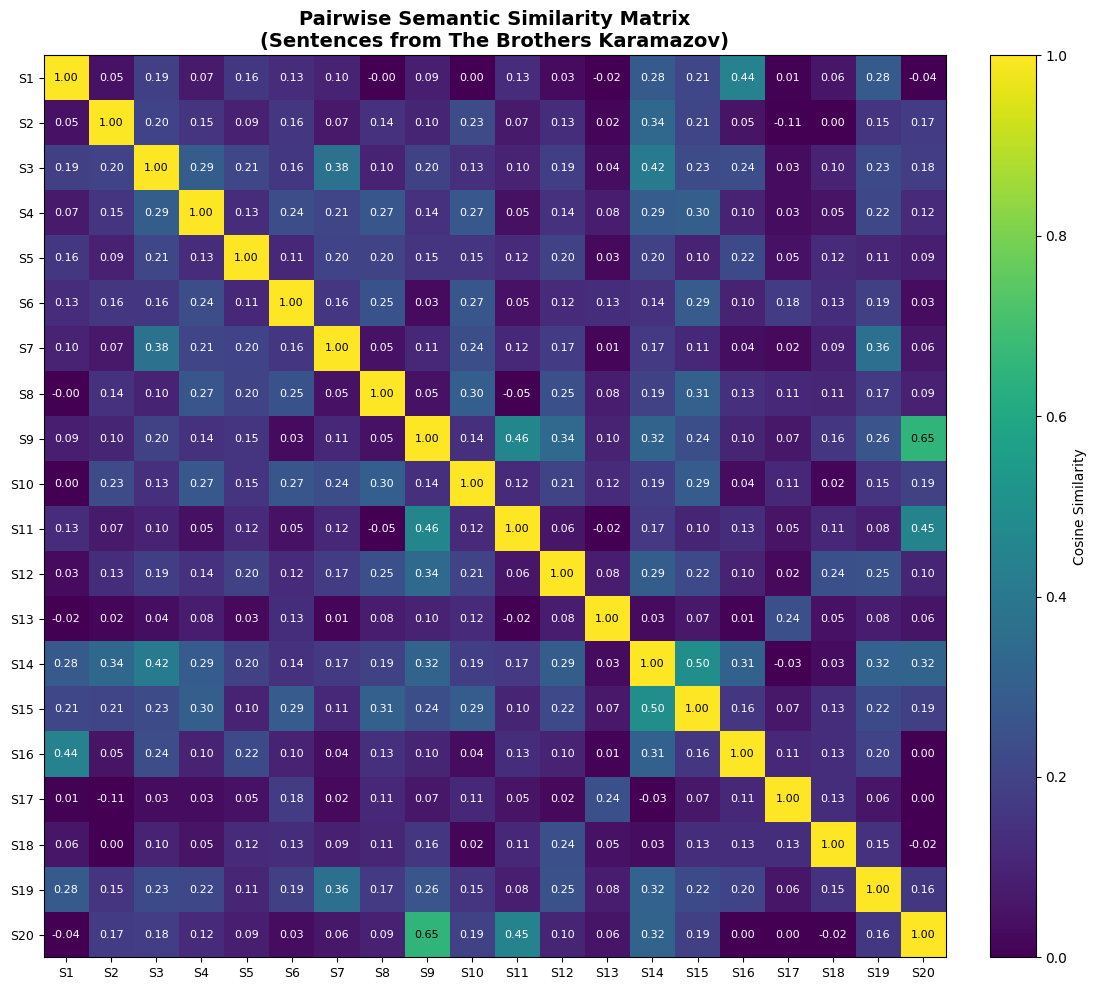


SENTENCE REFERENCE (The Brothers Karamazov Sample):
S1: A few followed him, but the greater number dispersed, hastening to service
S2: Old phrases and old gestures
S3: God grant that your heart will attain the answer on earth, and may God bless your path.”

			The elder raised his hand and would have made the sign of the cross over Ivan from where he stood
S4: How then could my soul beget a flunkey like you?”

			“My dear fellow, I know a most charming and attractive young Russian gentleman, a young thinker and a great lover of literature and art, the author of a promising poem entitled The Grand Inquisitor
S5: They asked Mitya whether he admitted having written the letter
S6: We heard of you, Father, we heard of you
S7: Ivan sank back in his chair
S8: I’ll unmask you.”

			“To my thinking, you’d better keep quiet, for what can you accuse me of, considering my absolute innocence
S9: But Alyosha had an irresistible attraction for him
S10: “Well, Karamazov, or whatever it is, but I alwa

In [24]:
# --- Analysis for The Brothers Karamazov (Revised) ---

# We will use NEW variable names to avoid conflicts
brothers_sentences = []
brothers_similarity_matrix = []

if brothers_sents:
    # 1. Take a random sample of 20 sentences
    sample_size = 20
    if len(brothers_sents) > sample_size:
        brothers_sentences = random.sample(brothers_sents, sample_size)
    else:
        brothers_sentences = brothers_sents
    
    print(f"--- Using {sample_size} random sentences from The Brothers Karamazov ---")

    # 2. Generate embeddings
    embeddings = model.encode(brothers_sentences)

    # 3. Create the 2D PCA Plot
    pca = PCA(n_components=2)
    points = pca.fit_transform(embeddings)

    fig, ax1 = plt.subplots(figsize=(12, 8))
    
    scatter = ax1.scatter(points[:, 0], points[:, 1], c=range(len(brothers_sentences)), 
                          cmap='tab20', s=150, alpha=0.7, edgecolors='black')

    # Add labels
    for i, (s, (x, y)) in enumerate(zip(brothers_sentences, points)):
        label = f"S{i+1}"
        ax1.annotate(label, (x, y), fontsize=10, ha='center',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6, ec='none'),
                    xytext=(0, 10), textcoords='offset points')

    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax1.set_title("2D Semantic Space of Sentences\n(from The Brothers Karamazov - via PCA)", 
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4. Create the Similarity Matrix Plot
    fig, ax2 = plt.subplots(figsize=(12, 10))
    # Save to the new variable
    brothers_similarity_matrix = util.cos_sim(embeddings, embeddings).numpy()
    
    im = ax2.imshow(brothers_similarity_matrix, cmap='viridis', vmin=0, vmax=1)
    cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label('Cosine Similarity')

    ax2.set_xticks(range(len(brothers_sentences)))
    ax2.set_yticks(range(len(brothers_sentences)))
    short_labels = [f"S{i+1}" for i in range(len(brothers_sentences))]
    ax2.set_xticklabels(short_labels, fontsize=9)
    ax2.set_yticklabels(short_labels, fontsize=9)
    ax2.set_title("Pairwise Semantic Similarity Matrix\n(Sentences from The Brothers Karamazov)", 
                  fontsize=14, fontweight='bold')
    
    # Add similarity scores as text
    for i in range(len(brothers_sentences)):
        for j in range(len(brothers_sentences)):
            text_color = 'white' if brothers_similarity_matrix[i, j] < 0.5 else 'black'
            ax2.text(j, i, f'{brothers_similarity_matrix[i, j]:.2f}',
                    ha="center", va="center", color=text_color, fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Print the sentence reference
    print("\n" + "="*80)
    print("SENTENCE REFERENCE (The Brothers Karamazov Sample):")
    print("="*80)
    for i, sent in enumerate(brothers_sentences):
        print(f"S{i+1}: {sent}")
    print("="*80)

else:
    print("Brothers Karamazov sentence data ('brothers_sents') not found.")

In [25]:
# This cell now checks for the NEW, specific variable names

if 'brothers_similarity_matrix' in locals() and 'brothers_sentences' in locals():
    print("\nTOP 5 MOST SIMILAR SENTENCE PAIRS (The Brothers Karamazov):")
    print("="*80)

    # Get upper triangle indices
    pairs = []
    for i in range(len(brothers_sentences)):
        for j in range(i+1, len(brothers_sentences)):
            # Use the new variables
            pairs.append((i, j, brothers_similarity_matrix[i, j]))

    # Sort by similarity score
    pairs.sort(key=lambda x: x[2], reverse=True)

    # Display top 5
    for rank, (i, j, score) in enumerate(pairs[:5], 1):
        print(f"{rank}. Similarity: {score:.4f}")
        # Use the new variable
        print(f"   S{i+1}: {brothers_sentences[i]}")
        print(f"   S{j+1}: {brothers_sentences[j]}")
        print()
else:
    print("Run the cell above to generate the data for 'The Brothers Karamazov' first.")


TOP 5 MOST SIMILAR SENTENCE PAIRS (The Brothers Karamazov):
1. Similarity: 0.6538
   S9: But Alyosha had an irresistible attraction for him
   S20: What struck Alyosha most in that face was its expression of childlike good nature

2. Similarity: 0.4954
   S14: An imploring smile lighted up his face; from time to time he raised his hand, as though to check the storm, and, of course, a gesture from him would have been enough to end the scene; but he seemed to be waiting for something and watched them intently as though trying to make out something which was not perfectly clear to him
   S15: I ran across the garden to the fence﻿ ﻿… and there Grigory caught me, when I was sitting on the fence.”

			At that point he raised his eyes at last and looked at his listeners

3. Similarity: 0.4579
   S9: But Alyosha had an irresistible attraction for him
   S11: When Alyosha came in, dinner was over, but coffee and preserves had been served

4. Similarity: 0.4485
   S11: When Alyosha came in, din